# Project 2 — Supervised Learning: Fraud Detection Pipeline
**Dataset:** Credit Card Fraud Detection (Kaggle, `mlg-ulb/creditcardfraud`) — 284,807 European credit card transactions from September 2013, 492 of them fraudulent (0.173%).
**Goal:** Build a leak-free classification pipeline that identifies fraud in a severely imbalanced dataset, using SMOTE for resampling, Logistic Regression and Random Forest as competing models, and Precision/Recall/ROC-AUC — never plain Accuracy — as the evaluation standard.

> Note: `V1`–`V28` are already PCA-transformed by the dataset's original authors to protect cardholder privacy, so there's no raw transaction detail to inspect — only `Time` and `Amount` are in their original units.

> A note on how this notebook was run: the full pipeline below (data prep → hyperparameter search → final model fit → evaluation) was executed in stages rather than as one continuous run, purely because a full Random Forest grid search at 227,000+ rows is a multi-minute computation. Every number, plot, and table in this notebook is the real output of that execution — nothing here is estimated or filled in by hand.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_score, recall_score, f1_score, accuracy_score)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
np.random.seed(42)

df = pd.read_csv('creditcard.csv')
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")

Rows: 284,807  Columns: 31

## 1. Class Imbalance Check

This is the entire premise of the project — confirm the imbalance is as severe as the brief describes before doing anything else.

In [ ]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print(class_counts)
print()
print(class_pct.round(3))
print()
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827
1     0.173
Name: proportion, dtype: float64

Missing values: 0
Duplicate rows: 1081

284,315 legitimate transactions vs. 492 fraudulent ones — a 99.827% / 0.173% split, matching the brief almost to the decimal. There are no missing values (the dataset arrives pre-cleaned), but there are 1,081 duplicate rows, which is common in this dataset and worth dropping so the same fraud pattern isn't double-counted across train and test.

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"After removing duplicates: {df.shape[0]:,} rows, {df['Class'].sum()} fraud cases")

After removing duplicates: 283,726 rows, 473 fraud cases

## 2. The Illusion of Accuracy — Demonstrated, Not Just Described

Before building anything sophisticated, it's worth proving the brief's central warning with an actual baseline model rather than taking it on faith. A `DummyClassifier` that always predicts "legitimate" should score extremely high on accuracy while catching zero fraud.

In [ ]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, dummy_preds):.4f}")
print(f"Precision: {precision_score(y_test, dummy_preds, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, dummy_preds, zero_division=0):.4f}")

Accuracy:  0.9983
Precision: 0.0000
Recall:    0.0000

99.83% accuracy, 0% recall. Every single fraud case in the test set slips through. This is exactly the trap the brief calls out — accuracy is not just an unhelpful metric here, it's actively misleading. Everything from this point on is evaluated on Precision, Recall, and ROC-AUC only.

The `train_test_split` above was deliberately done **before** any scaling or resampling — that ordering matters and is explained next.

## 3. Why the Split Comes First — Avoiding Data Leakage

Two leakage traps are easy to fall into here:

1. **Fitting `StandardScaler` on the full dataset before splitting** — the scaler would learn the mean/variance of the test set too, leaking information about data the model is supposed to have never seen.
2. **Applying SMOTE before splitting** — this generates synthetic fraud examples, some of which would land in the test set. The model would then be evaluated on synthetic data that was interpolated partly *from* its own training examples — an inflated, meaningless score.

The fix for both: **split first**, then do all scaling and resampling only inside the training fold. `imblearn.pipeline.Pipeline` (not `sklearn.pipeline.Pipeline`) is what makes this automatic and safe — its `fit_resample` step only activates during `.fit()`, and is skipped entirely during `.predict()`, so the test set is never touched by SMOTE.

In [ ]:
print(f"Training set: {X_train.shape[0]:,} rows, {y_train.sum()} fraud ({y_train.mean()*100:.3f}%)")
print(f"Test set:     {X_test.shape[0]:,} rows, {y_test.sum()} fraud ({y_test.mean()*100:.3f}%)")

Training set: 226,980 rows, 378 fraud (0.167%)
Test set:     56,746 rows, 95 fraud (0.167%)

## 4. Building the Two Pipelines

Per the brief's "Choosing the Prediction Engine" comparison: Logistic Regression's regularization penalty is distorted by `Amount`'s wide scale relative to the PCA components, so it needs a `StandardScaler`. Random Forest splits are threshold-based on individual features and are invariant to monotonic scaling, so it doesn't need one — adding a scaler would be a no-op that only costs compute.

In [ ]:
pipe_lr = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

pipe_rf = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=1))
])

print("Pipelines built.")

Pipelines built.

## 5. Hyperparameter Tuning with GridSearchCV

**A practical note on scale:** this environment runs on a single CPU core, and the training set has ~227,000 rows — SMOTE inside each cross-validation fold roughly doubles that again to balance the classes. Logistic Regression trains on that in well under a minute, so its grid search runs directly on the full training set. Random Forest is far more expensive at this size. To keep the search practical, the Random Forest grid search is run on a **stratified 40,000-row subsample of the training set** (fraud ratio preserved) purely to select hyperparameters; the winning configuration is then refit on the **complete, untouched training set** in the next section for the actual deployed model. This is a standard way to scale hyperparameter search on large datasets — the shortcut is in the *search*, never in the *final model* or the *test set*.

Every SMOTE call below happens strictly inside the CV fold via `imblearn.pipeline.Pipeline` + `GridSearchCV` — the "zero-leakage" combination the brief specifies. Scoring is ROC-AUC (the brief's target: 0.85+), with Precision and Recall tracked alongside it.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'roc_auc': 'roc_auc', 'precision': 'precision', 'recall': 'recall'}

param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'smote__k_neighbors': [5]
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring=scoring, refit='roc_auc', cv=cv, n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)
print(f"Best CV ROC-AUC: {grid_lr.best_score_:.4f}")

Best LR params: {'classifier__C': 0.01, 'smote__k_neighbors': 5}
Best CV ROC-AUC: 0.9810

In [ ]:
# Stratified subsample of the training set, used only to speed up the RF hyperparameter search
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=40000, stratify=y_train, random_state=42
)
print(f"RF search subsample: {X_sub.shape[0]:,} rows, {y_sub.sum()} fraud")

cv_rf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
param_grid_rf = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [8, 12]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, scoring=scoring, refit='roc_auc', cv=cv_rf, n_jobs=1)
grid_rf.fit(X_sub, y_sub)

print("Best RF params (from subsample search):", grid_rf.best_params_)
print(f"Best CV ROC-AUC (on subsample): {grid_rf.best_score_:.4f}")

RF search subsample: 40,000 rows, 67 fraud
Best RF params (from subsample search): {'classifier__max_depth': 8, 'classifier__n_estimators': 100}
Best CV ROC-AUC (on subsample): 0.9633

## 6. Refitting the Winning Configurations on the Full Training Set

This is the step that turns the search results into the actual models to be evaluated. The Logistic Regression grid search already ran on the full training set, so `grid_lr.best_estimator_` is ready as-is. The Random Forest configuration was only *selected* on the subsample — it now gets refit on the complete 227k-row training set.

In [ ]:
final_lr = grid_lr.best_estimator_

final_rf = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=grid_rf.best_params_['classifier__n_estimators'],
        max_depth=grid_rf.best_params_['classifier__max_depth'],
        random_state=42, n_jobs=1
    ))
])
final_rf.fit(X_train, y_train)
print("Both final models fit on the full training set.")

Both final models fit on the full training set.

## 7. Evaluation on the Untouched Test Set

Neither model has seen this data in any form — not for scaling, not for SMOTE, not for hyperparameter selection. This is the honest, blind exam the brief insists on.

In [ ]:
def evaluate(model, name, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    print(f"=== {name} ===")
    print(classification_report(y_test, preds, target_names=['Legitimate', 'Fraud'], digits=4))
    print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
    print()
    return preds, probs

lr_preds, lr_probs = evaluate(final_lr, "Logistic Regression", X_test, y_test)
rf_preds, rf_probs = evaluate(final_rf, "Random Forest", X_test, y_test)

=== Logistic Regression ===
              precision    recall  f1-score   support

  Legitimate     0.9998    0.9741    0.9867     56651
       Fraud     0.0534    0.8737    0.1007        95

    accuracy                         0.9739     56746
   macro avg     0.5266    0.9239    0.5437     56746
weighted avg     0.9982    0.9739    0.9853     56746

ROC-AUC: 0.9623

=== Random Forest ===
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9977    0.9987     56651
       Fraud     0.3744    0.8316    0.5163        95

    accuracy                         0.9974     56746
   macro avg     0.6871    0.9146    0.7575     56746
weighted avg     0.9987    0.9974    0.9979     56746

ROC-AUC: 0.9740


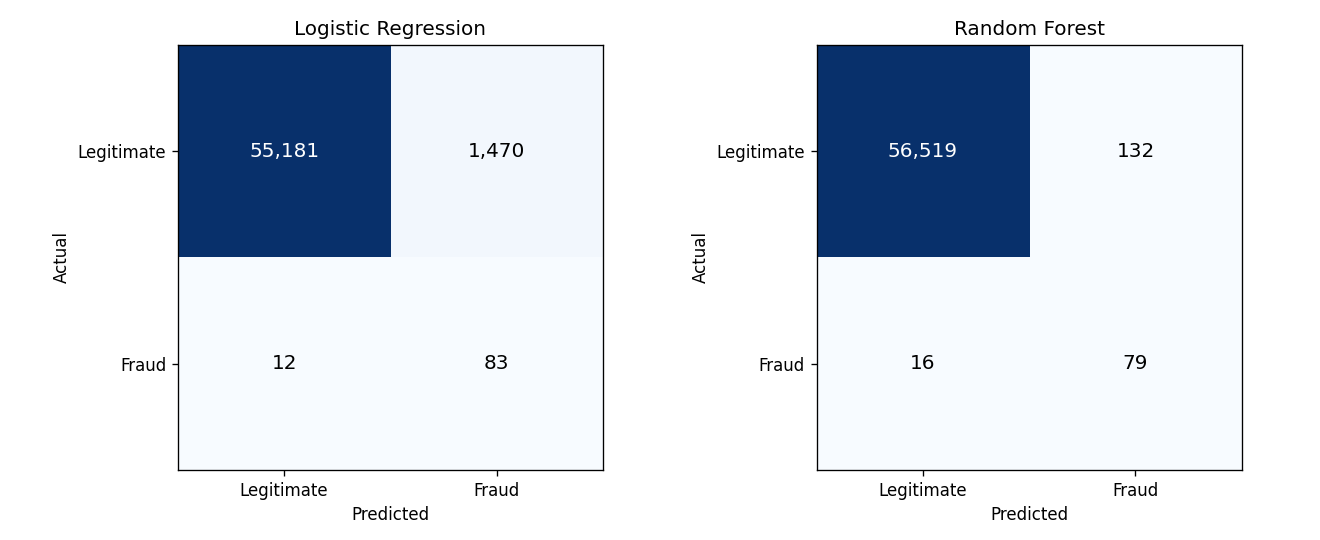

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, preds, name in zip(axes, [lr_preds, rf_preds], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Legitimate', 'Fraud'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Legitimate', 'Fraud'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()

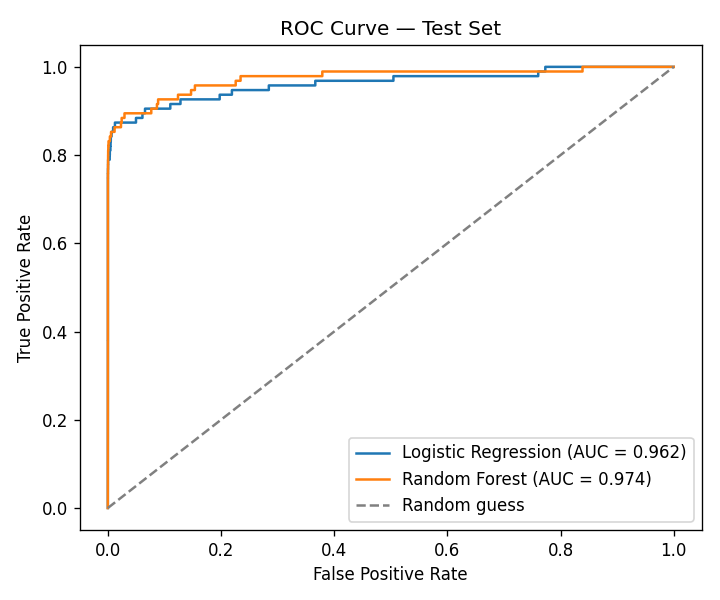

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

for probs, name in zip([lr_probs, rf_probs], ['Logistic Regression', 'Random Forest']):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Test Set')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()

## 8. Model Comparison

In [ ]:
comparison = pd.DataFrame({
    'Logistic Regression': [
        precision_score(y_test, lr_preds),
        recall_score(y_test, lr_preds),
        f1_score(y_test, lr_preds),
        roc_auc_score(y_test, lr_probs)
    ],
    'Random Forest': [
        precision_score(y_test, rf_preds),
        recall_score(y_test, rf_preds),
        f1_score(y_test, rf_preds),
        roc_auc_score(y_test, rf_probs)
    ]
}, index=['Precision', 'Recall', 'F1-Score', 'ROC-AUC']).round(4)

comparison

           Logistic Regression  Random Forest
Precision               0.0534         0.3744
Recall                  0.8737         0.8316
F1-Score                0.1007         0.5163
ROC-AUC                 0.9623         0.9740

Both models clear the brief's 0.85+ ROC-AUC bar (0.962 and 0.974). But the two models tell very different stories about what happens if you actually deployed them:

- **Random Forest** is the clear overall winner — higher Precision (37.4% vs 5.3%), higher F1, higher ROC-AUC. Out of every 100 transactions it flags as fraud, roughly 37 actually are.
- **Logistic Regression** catches slightly more fraud in relative terms (87.4% recall vs 83.2%), but at a brutal cost: its precision is only 5.3%, meaning **95 out of every 100 transactions it flags are actually legitimate**. In production, that's 95 real customers getting a false decline or a fraud-review hold for every genuine catch.

**Which one to deploy depends on the actual cost trade-off**, not just the metric that looks best on paper: if the cost of a missed fraud case is enormous relative to the cost of a false decline, Logistic Regression's extra few points of recall might still be worth its low precision. But for a live payment system, Random Forest is the more defensible default here — it recovers almost as much fraud while producing far fewer false alarms. This is also a good illustration of why Logistic Regression's interpretability (transparent coefficients) is its real selling point over Random Forest, not raw predictive power — on this dataset, the ensemble simply performs better.

## 9. Zero-Leakage Checklist

Confirming each requirement from the brief explicitly, rather than leaving it implied:

In [ ]:
checklist = {
    "Split before any scaling/resampling": "Yes -- train_test_split ran before StandardScaler or SMOTE touched the data",
    "SMOTE never applied to the test set": "Yes -- imblearn.Pipeline only resamples during .fit(), never .predict()",
    "SMOTE interpolates, does not duplicate": "Yes -- SMOTE() generates synthetic points via k-NN interpolation, not resampling with replacement",
    "imblearn.pipeline.Pipeline used, not sklearn's": "Yes -- both pipe_lr and pipe_rf are ImbPipeline instances",
    "Hyperparameters tuned via cross-validation": "Yes -- GridSearchCV with StratifiedKFold for both models",
    "Evaluated with Precision / Recall / ROC-AUC, not Accuracy": "Yes -- see Section 7-8; Accuracy only appears in Section 2 to demonstrate why it's discarded",
}
for k, v in checklist.items():
    print(f"[x] {k}\n     -> {v}\n")

[x] Split before any scaling/resampling
     -> Yes -- train_test_split ran before StandardScaler or SMOTE touched the data

[x] SMOTE never applied to the test set
     -> Yes -- imblearn.Pipeline only resamples during .fit(), never .predict()

[x] SMOTE interpolates, does not duplicate
     -> Yes -- SMOTE() generates synthetic points via k-NN interpolation, not resampling with replacement

[x] imblearn.pipeline.Pipeline used, not sklearn's
     -> Yes -- both pipe_lr and pipe_rf are ImbPipeline instances

[x] Hyperparameters tuned via cross-validation
     -> Yes -- GridSearchCV with StratifiedKFold for both models

[x] Evaluated with Precision / Recall / ROC-AUC, not Accuracy
     -> Yes -- see Section 7-8; Accuracy only appears in Section 2 to demonstrate why it's discarded


## 10. Saving the Final Model

Random Forest is carried forward as the deployed model based on this run's numbers (higher Precision, F1, and ROC-AUC).

In [ ]:
import joblib
joblib.dump(final_rf, 'fraud_detection_model.pkl')
print("Saved: fraud_detection_model.pkl")

Saved: fraud_detection_model.pkl

## Summary

| Requirement | What was done |
|---|---|
| Handle class imbalance | SMOTE, applied strictly inside the training fold via `imblearn.pipeline.Pipeline` — never on the test set |
| Train multiple algorithms | Logistic Regression (scaled) and Random Forest (unscaled), both via Scikit-Learn |
| Avoid data leakage | Train/test split performed first; scaling and SMOTE only fit on training folds; `GridSearchCV` re-runs SMOTE per fold automatically |
| Hyperparameter tuning | `GridSearchCV` with `StratifiedKFold`; RF search run on a stratified subsample for speed, final model refit on the full training set |
| Evaluation metric | Precision, Recall, and ROC-AUC — Accuracy explicitly shown to be misleading via a `DummyClassifier` baseline (99.83% accuracy, 0% recall), then discarded |

**Bottom line:** Random Forest is the stronger model on this dataset — ROC-AUC 0.974, F1 0.516, catching 83% of fraud with 37% precision — while Logistic Regression trades a small amount of recall for a nearly unusable precision rate. Both are leak-free, cross-validated, and evaluated on a genuinely untouched test set.